# Lab 1: Understanding Deep Learning Requires Rethinking Generalization

### Introduction

This lab is based on the paper ["Understanding Deep Learning Requires Rethinking Generalization"](https://arxiv.org/abs/1611.03530) by Zhang et al. (ICLR 2017). The paper presents a striking observation: deep neural networks can easily memorize training data with **completely random labels**, achieving near-perfect training accuracy while (unsurprisingly) failing to generalize.

This challenges classical learning theory, which suggests that models with enough capacity to memorize noise should generalize poorly even on real data. Yet in practice, the same overparameterized networks generalize remarkably well on true labels.

### Objectives

1. Observe that overparameterized networks achieve near-perfect training accuracy on MNIST
2. Demonstrate that the same network can memorize **random labels** (zero generalization)
3. Investigate the effect of **model capacity** (hidden size) on training and generalization
4. Test whether **weight decay regularization** can prevent memorization or improve generalization
5. Discuss what these results mean for classical generalization theory

### Setup

We begin by importing the necessary libraries and preparing the MNIST dataset. We use a **10,000-sample subset** of the training data — this keeps training fast while still being sufficient to demonstrate the generalization phenomena from the paper (the model is heavily overparameterized relative to the dataset size). The device is auto-detected to work on CUDA, MPS (Apple Silicon), or CPU.

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt

# Auto-detect device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

transform = transforms.Compose([transforms.ToTensor()])
batch_size = 256

full_train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

# Use a 10k subset for training — fast and still heavily overparameterized
subset_size: int = 10_000
train_dataset = Subset(full_train_dataset, list(range(subset_size)))

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Using device: cuda
Training samples: 10000, Test samples: 10000


### Explore the Data

Let's visualize a few samples from the MNIST dataset to understand what we're working with.

Batch shape: torch.Size([256, 1, 28, 28])
Target shape: torch.Size([256])


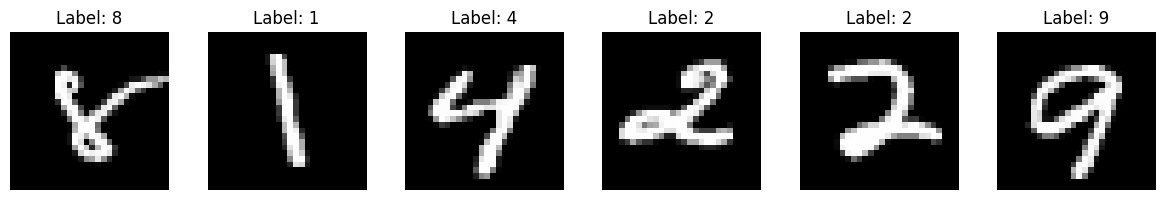

In [16]:
examples = iter(train_loader)
example_data, example_targets = next(examples)

print(f"Batch shape: {example_data.shape}")  # [batch_size, channels, height, width]
print(f"Target shape: {example_targets.shape}")  # [batch_size]

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(example_data[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {example_targets[i].item()}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Exercise 1: Define the Model

Implement a 3-layer MLP (Multi-Layer Perceptron) for MNIST classification. The architecture should be:

- **Input**: Flattened 28×28 image → 784 features
- **Hidden layer 1**: Linear(784, hidden_size) + ReLU
- **Hidden layer 2**: Linear(hidden_size, hidden_size) + ReLU
- **Output layer**: Linear(hidden_size, 10)

The `hidden_size` parameter controls model capacity — we will experiment with different values later.

In [17]:
class Net(nn.Module):
    def __init__(
        self, input_size: int = 784, hidden_size: int = 1024, num_classes: int = 10
    ) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Flatten input, pass through layers with ReLU activations
        return self.network(x)

### Training Utilities

The following helper functions are provided for training and evaluation. The `train_model` function:
1. Creates a `Net` with the specified `hidden_size`
2. Trains using Adam optimizer with cross-entropy loss
3. Tracks both **train** and **test** accuracy after each epoch
4. Returns the accuracy histories for plotting

In [18]:
def evaluate(model: nn.Module, data_loader: DataLoader) -> float:
    """Compute accuracy on a dataset."""
    model.eval()
    correct: int = 0
    total: int = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs: torch.Tensor = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


def train_model(
    train_loader: DataLoader,
    test_loader: DataLoader,
    hidden_size: int = 1024,
    num_epochs: int = 10,
    weight_decay: float = 0.0,
) -> tuple[list[float], list[float], nn.Module]:
    """Train a Net and return (train_accuracies, test_accuracies, model)."""
    model: nn.Module = Net(hidden_size=hidden_size).to(device)
    criterion: nn.Module = nn.CrossEntropyLoss()
    optimizer: optim.Optimizer = optim.Adam(
        model.parameters(), lr=1e-3, weight_decay=weight_decay
    )

    train_accuracies: list[float] = []
    test_accuracies: list[float] = []

    for epoch in range(num_epochs):
        model.train()
        running_loss: float = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs: torch.Tensor = model(images)
            loss: torch.Tensor = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss: float = running_loss / len(train_loader)
        train_acc: float = evaluate(model, train_loader)
        test_acc: float = evaluate(model, test_loader)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, "
            f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}"
        )

    return train_accuracies, test_accuracies, model

### Exercise 2: Train on True Labels

Train the model on the original MNIST labels using `hidden_size=1024` and `num_epochs=5`. Store the results and plot the train/test accuracy curves.

**Task:**
1. Call `train_model` with the true-label data loaders
2. Plot train accuracy and test accuracy vs. epoch on the same axes
3. Observe: does the model generalize well?

Epoch [1/5], Loss: 0.6895, Train Acc: 0.9112, Test Acc: 0.9009
Epoch [2/5], Loss: 0.2634, Train Acc: 0.9428, Test Acc: 0.9248
Epoch [3/5], Loss: 0.1727, Train Acc: 0.9560, Test Acc: 0.9316
Epoch [4/5], Loss: 0.1406, Train Acc: 0.9744, Test Acc: 0.9410
Epoch [5/5], Loss: 0.0915, Train Acc: 0.9829, Test Acc: 0.9474


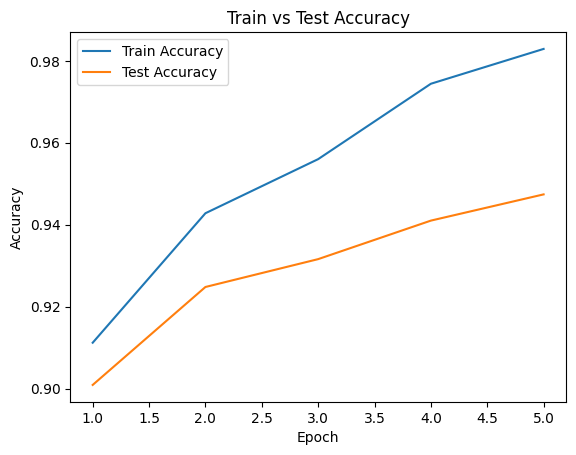

In [19]:
# Note: train_model now returns (train_accs, test_accs, model) — unpack accordingly
train_accs, test_accs, model = train_model(
    train_loader=train_loader,
    test_loader=test_loader,
    hidden_size=1024,
    num_epochs=5,
)

plt.plot(range(1, 6), train_accs, label="Train Accuracy")
plt.plot(range(1, 6), test_accs, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.show()

Model generalizes well, as both training and test accuracy exceed 90%, and the generalization gap between them is relatively small.

### Exercise 3: Random Labels Experiment

This is the **key experiment** from the paper. We replace the true labels with **completely random labels** drawn uniformly from {0, 1, ..., 9}. Since the labels have no correlation with the images, a model that achieves high training accuracy is simply **memorizing** the dataset.

**Task:**
1. Implement the `RandomLabels` dataset wrapper below
2. Create data loaders with random labels (wrap the existing `train_dataset`)
3. Train the model for **25 epochs** (memorization takes longer than learning true patterns)
4. Observe: can the network memorize random labels? What happens to test accuracy?

In [20]:
class RandomLabels(Dataset):
    """Wraps a dataset and replaces labels with random ones."""

    def __init__(
        self, base_dataset: Dataset, num_classes: int = 10, seed: int = 42
    ) -> None:
        self.base: Dataset = base_dataset
        # TODO: Generate random labels for the entire dataset using the given seed
        # Use torch.Generator().manual_seed(seed) for reproducibility
        generator = torch.Generator().manual_seed(seed)
        self.random_labels = torch.randint(
            low=0, high=num_classes, size=(len(self.base),), generator=generator
        )

    def __len__(self) -> int:
        return len(self.base)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        # TODO: Return the original image with a random label
        x, _ = self.base[idx]
        y = int(self.random_labels[idx])
        return x, y

In [21]:
# TODO: Wrap train_dataset and test_dataset with RandomLabels, create data loaders
# Then train for 25 epochs with hidden_size=1024
# Note: train_model returns (train_accs, test_accs, model) — unpack accordingly
random_labels_train_dataset = RandomLabels(train_dataset)
random_labels_test_dataset = RandomLabels(test_dataset)
random_labels_train_dataset_loader = DataLoader(
    dataset=random_labels_train_dataset, batch_size=batch_size, shuffle=True
)
random_labels_test_dataset_loader = DataLoader(
    dataset=random_labels_test_dataset, batch_size=batch_size, shuffle=False
)

random_train_accs, random_test_accs, random_lables_model = train_model(
    train_loader=random_labels_train_dataset_loader,
    test_loader=random_labels_test_dataset_loader,
    hidden_size=1024,
    num_epochs=25,
)

Epoch [1/25], Loss: 2.3061, Train Acc: 0.1260, Test Acc: 0.1015
Epoch [2/25], Loss: 2.2978, Train Acc: 0.1469, Test Acc: 0.1009
Epoch [3/25], Loss: 2.2848, Train Acc: 0.1694, Test Acc: 0.0999
Epoch [4/25], Loss: 2.2665, Train Acc: 0.1840, Test Acc: 0.1018
Epoch [5/25], Loss: 2.2326, Train Acc: 0.2094, Test Acc: 0.1007
Epoch [6/25], Loss: 2.1858, Train Acc: 0.2435, Test Acc: 0.1011
Epoch [7/25], Loss: 2.1070, Train Acc: 0.3164, Test Acc: 0.1007
Epoch [8/25], Loss: 2.0271, Train Acc: 0.3324, Test Acc: 0.1004
Epoch [9/25], Loss: 1.9363, Train Acc: 0.3798, Test Acc: 0.1023
Epoch [10/25], Loss: 1.7911, Train Acc: 0.4125, Test Acc: 0.1005
Epoch [11/25], Loss: 1.6769, Train Acc: 0.4872, Test Acc: 0.1016
Epoch [12/25], Loss: 1.5399, Train Acc: 0.5359, Test Acc: 0.1011
Epoch [13/25], Loss: 1.4233, Train Acc: 0.6210, Test Acc: 0.1015
Epoch [14/25], Loss: 1.2840, Train Acc: 0.6480, Test Acc: 0.1017
Epoch [15/25], Loss: 1.1514, Train Acc: 0.6907, Test Acc: 0.1044
Epoch [16/25], Loss: 1.0197, Train

The network is able to memorize the training data. Training accuracy increases to over 90%, while test accuracy remains around 10%, which corresponds to random guessing for a 10-class classification problem. This shows that the model does not learn meaningful patterns but instead memorizes the training labels.

### Exercise 4: Comparison Plot

Create a side-by-side comparison of training on **true labels** vs. **random labels**.

**Task:**
1. Create a figure with 2 subplots
2. Left subplot: true labels — plot train accuracy, test accuracy, and generalization gap
3. Right subplot: random labels — plot train accuracy, test accuracy, and generalization gap
4. The **generalization gap** is defined as `train_accuracy - test_accuracy`

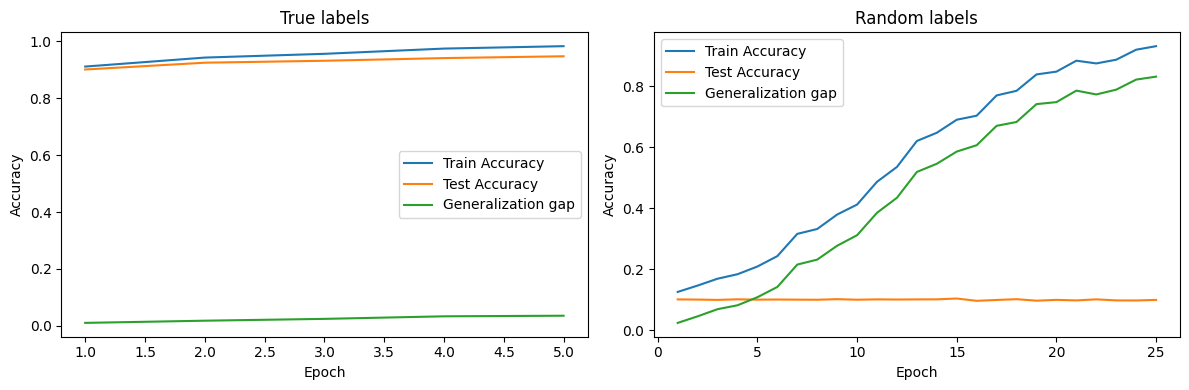

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data = [(train_accs, test_accs), (random_train_accs, random_test_accs)]
titles = ["True labels", "Random labels"]

for i in range(2):
    train = data[i][0]
    test = data[i][1]
    epochs = range(1, len(train) + 1)
    gap = [tr - te for tr, te in zip(train, test)]

    axes[i].plot(epochs, train, label="Train Accuracy")
    axes[i].plot(epochs, test, label="Test Accuracy")
    axes[i].plot(epochs, gap, label="Generalization gap")

    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Accuracy")
    axes[i].legend()

plt.tight_layout()
plt.show()

### Exercise 5: Effect of Model Capacity

How does the size of the hidden layers affect the model's ability to fit and generalize?

**Task:**
1. Train models with `hidden_size` values `[50, 100, 200, 500, 1024]` on **true labels** for 10 epochs each
2. Record the **final** train and test accuracy for each hidden size
3. Plot final train accuracy and test accuracy vs. hidden size
4. Discuss: does a bigger model lead to worse generalization?

In [27]:
# TODO: Train models with different hidden sizes and collect final accuracies
hidden_sizes = [50, 100, 200, 500, 1024]
size_to_final_train_acc = []
size_to_final_test_acc = []

for h_s in hidden_sizes:
    print(f"--------------- Hidden size {h_s} ---------------")
    train_acc, test_acc, _ = train_model(
        train_loader=train_loader,
        test_loader=test_loader,
        hidden_size=h_s,
        num_epochs=10,
    )
    print("--------------------------------------------------")
    size_to_final_train_acc.append(train_acc[-1])
    size_to_final_test_acc.append(test_acc[-1])

Epoch [1/10], Loss: 1.7707, Train Acc: 0.8002, Test Acc: 0.7978
Epoch [2/10], Loss: 0.6518, Train Acc: 0.8810, Test Acc: 0.8748
Epoch [3/10], Loss: 0.3981, Train Acc: 0.9045, Test Acc: 0.8943
Epoch [4/10], Loss: 0.3347, Train Acc: 0.9175, Test Acc: 0.9030
Epoch [5/10], Loss: 0.3013, Train Acc: 0.9245, Test Acc: 0.9111
Epoch [6/10], Loss: 0.2762, Train Acc: 0.9260, Test Acc: 0.9103
Epoch [7/10], Loss: 0.2660, Train Acc: 0.9324, Test Acc: 0.9141
Epoch [8/10], Loss: 0.2392, Train Acc: 0.9350, Test Acc: 0.9160
Epoch [9/10], Loss: 0.2286, Train Acc: 0.9382, Test Acc: 0.9201
Epoch [10/10], Loss: 0.2148, Train Acc: 0.9432, Test Acc: 0.9220
Epoch [1/10], Loss: 1.4632, Train Acc: 0.8341, Test Acc: 0.8261
Epoch [2/10], Loss: 0.4627, Train Acc: 0.8934, Test Acc: 0.8802
Epoch [3/10], Loss: 0.3404, Train Acc: 0.9160, Test Acc: 0.9037
Epoch [4/10], Loss: 0.2914, Train Acc: 0.9275, Test Acc: 0.9123
Epoch [5/10], Loss: 0.2602, Train Acc: 0.9298, Test Acc: 0.9127
Epoch [6/10], Loss: 0.2466, Train Acc: 

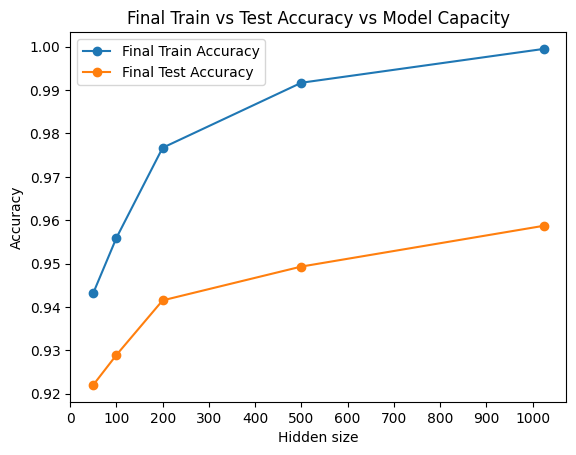

In [35]:
# TODO: Plot final train and test accuracy vs. hidden size

plt.plot(
    hidden_sizes, size_to_final_train_acc, marker="o", label="Final Train Accuracy"
)
plt.plot(hidden_sizes, size_to_final_test_acc, marker="o", label="Final Test Accuracy")
plt.xticks(range(0, 1050, 100))
plt.xlabel("Hidden size")
plt.ylabel("Accuracy")
plt.title("Final Train vs Test Accuracy vs Model Capacity")
plt.legend()
plt.show()

Increasing model capacity improves both training and test accuracy. Therefore, larger models do not lead to worse generalization in this experiment.However, the generalization gap increases with model capacity, which suggests that further increasing the model size may increase the risk of overfitting

### Exercise 6: Weight Decay Regularization

The paper argues that explicit regularization (such as weight decay) is **neither necessary nor sufficient** for generalization. Let's test this claim empirically.

Weight decay (L2 regularization) adds a penalty term $\lambda \|\mathbf{w}\|^2$ to the loss, discouraging large weights. The `train_model` function already supports a `weight_decay` parameter that is passed to the Adam optimizer.

We already know from Exercise 2 that the unregularized model generalizes well on true labels. The more interesting question is: **can weight decay prevent the network from memorizing random labels?**

**Task:**
1. Train models with `weight_decay` values `[1e-3, 1e-2, 1e-1]` on **random labels** for 10 epochs each (`hidden_size=1024`)
2. Plot final train accuracy vs. weight decay
3. Discuss: does weight decay prevent memorization? What does this say about the paper's claim?

In [38]:
# TODO: Train with different weight_decay values on random labels
weight_decays: list[float] = [1e-3, 1e-2, 1e-1]
weight_decays_to_final_train_acc = []
weight_decays_to_final_test_acc = []

for w_d in weight_decays:
    random_train_acc, random_test_acc, _ = train_model(
        train_loader=random_labels_train_dataset_loader,
        test_loader=random_labels_test_dataset_loader,
        hidden_size=1024,
        num_epochs=10,
        weight_decay=w_d,
    )
    weight_decays_to_final_train_acc.append(random_train_acc[-1])
    weight_decays_to_final_test_acc.append(random_test_acc[-1])

Epoch [1/10], Loss: 2.3049, Train Acc: 0.1228, Test Acc: 0.1041
Epoch [2/10], Loss: 2.3004, Train Acc: 0.1231, Test Acc: 0.1022
Epoch [3/10], Loss: 2.2981, Train Acc: 0.1024, Test Acc: 0.1035
Epoch [4/10], Loss: 2.2964, Train Acc: 0.1348, Test Acc: 0.1000
Epoch [5/10], Loss: 2.2930, Train Acc: 0.1326, Test Acc: 0.0985
Epoch [6/10], Loss: 2.2870, Train Acc: 0.1387, Test Acc: 0.1032
Epoch [7/10], Loss: 2.2847, Train Acc: 0.1525, Test Acc: 0.0985
Epoch [8/10], Loss: 2.2753, Train Acc: 0.1537, Test Acc: 0.1033
Epoch [9/10], Loss: 2.2722, Train Acc: 0.1590, Test Acc: 0.1002
Epoch [10/10], Loss: 2.2625, Train Acc: 0.1661, Test Acc: 0.1004
Epoch [1/10], Loss: 2.3036, Train Acc: 0.1053, Test Acc: 0.1053
Epoch [2/10], Loss: 2.3023, Train Acc: 0.1053, Test Acc: 0.1053
Epoch [3/10], Loss: 2.3022, Train Acc: 0.1053, Test Acc: 0.1053
Epoch [4/10], Loss: 2.3022, Train Acc: 0.1053, Test Acc: 0.1053
Epoch [5/10], Loss: 2.3022, Train Acc: 0.1037, Test Acc: 0.1037
Epoch [6/10], Loss: 2.3020, Train Acc: 

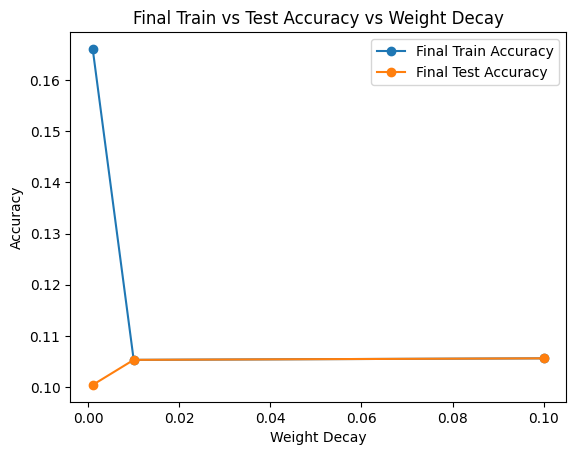

In [40]:
plt.plot(
    weight_decays,
    weight_decays_to_final_train_acc,
    marker="o",
    label="Final Train Accuracy",
)
plt.plot(
    weight_decays,
    weight_decays_to_final_test_acc,
    marker="o",
    label="Final Test Accuracy",
)
plt.xlabel("Weight Decay")
plt.ylabel("Accuracy")
plt.title("Final Train vs Test Accuracy vs Weight Decay")
plt.legend()
plt.show()

Increasing weight decay significantly reduces the model’s ability to memorize random labels. With strong regularization, both training and test accuracy remain around 10%, which corresponds to random guessing for a 10-class classification problem. This suggests that weight decay can limit memorization in this setting. However, this does not contradict the paper’s claim that explicit regularization is neither necessary nor sufficient for generalization, as memorization may still occur with different model sizes or longer training.

Compare our experimental setup and results with those reported in the paper. To what extent do our findings align with the original study? What similarities and discrepancies can be identified?

Our experimental results largely align with the findings reported in the paper. Similar to the original study, the network was able to memorize random labels, achieving high training accuracy while test accuracy remained at the level of random guessing. Additionally, larger models achieved higher training accuracy and still generalized well on real labels.

However, some discrepancies were observed. In our experiments, strong weight decay prevented the network from memorizing random labels within the limited number of training epochs. This differs slightly from the paper’s findings, which suggest that explicit regularization alone is not sufficient to prevent memorization. These differences may be explained by the smaller model size, shorter training time, and simpler experimental setup used in our experiments.

### Discussion Questions

**Q1:** In Exercise 6, you tested whether weight decay can prevent memorization or improve generalization. The paper's central claim is that explicit regularization is "neither necessary nor sufficient" for generalization. Based on your results, do you agree? If an unregularized model already generalizes well on true labels, what role (if any) does regularization actually play in deep learning?

**Q2:** The paper has over 6,000 citations, yet at its core it is based on a very simple experiment: training on random labels. Why do you think something so straightforward ended up having such a big impact on the field? What does this tell us about the value of empirical work vs. theoretical work in machine learning?

**A1**

Based on our experiments, I generally agree with the paper’s claim that explicit regularization is neither necessary nor sufficient for good generalization. In our experiments, the unregularized model already generalized well on true labels, achieving high test accuracy. This suggests that good generalization can emerge even without explicit regularization.

However, when training on random labels, strong weight decay reduced the model’s ability to memorize the training data. This shows that regularization can still influence the learning process. In practice, regularization acts as a constraint on model complexity by penalizing large weights, which can encourage the model to rely on more distributed representations rather than memorizing specific examples. As a result, regularization can help stabilize training and sometimes improve generalization, even if it is not strictly necessary

**A2**

The paper had a large impact because it challenged widely held assumptions about generalization in deep learning. Before this work, it was commonly believed that large neural networks should easily overfit and that explicit regularization was necessary to achieve good generalization. The simple experiment of training on random labels demonstrated that modern neural networks can perfectly memorize arbitrary data, yet still generalize well when trained on real labels.

This highlighted a gap between existing theoretical explanations and empirical observations in deep learning. The study shows the importance of empirical work in machine learning, as simple experiments can reveal surprising behaviors that theory does not yet explain. Empirical results often guide the development of new theoretical insights.